# 3.0 Data Distributions
---
---
I am going to do everything in this notebook and then split it up into more relevant notebooks since I want:
- Foundation, make the customer dataset
- 4 Firmographic, make country regions
- 1 Lifecycle / Value, basic RFM
- 2 Behavioural, shopping patterns --> persona backbone
- 3 Product Affinity, what can I get from the descriptions
- Triangulation, determine suitable personas from 1 - 4 and define business value
- Validation and testing and look for business relevant storyline

Once I see how all the above sits I can edit the portfolio appropriately

# Table Specifications
---
---

#### **Table name:** cleansed_retail_orders
- Fields: 15
- Rows: 1.067,371
- File Size: 9.5MB
- Approximate Memory Use: 256 MB

| **Field** | **Description** | **Data Type** | **Data Type Description** | **Example** |
| :--- | :--- | :--- | :--- | :--- |
| Invoice | This is the invoice number | Str | Number or C+Number for cancellations | 516171 |
| StockCode | This is the product code| Str | Number and additional admin/ops type letters | 22487 |
| Description | Full product description | Str | String of concatenated key words | PLASTERS IN TIN SPACEBOY |
| Quantity | number of products measure | Int 64 | There are negative numbers here for adjustments | 3 |
| InvoiceDate | Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| UnitPrice | Price of one line item | Float 64 | These are Pound Sterling and all positive | 0.39 |
| TotalPrice | Total price of lines items | Float 64 | This is Quantity x UnitPrice in Pound Sterling | 1.17 |
| CustomerHashID | Pseudonymised customer number | Str | Simulated hash using HMAC-SHA256 | 09c72970956ea... |
| Country | Full country names | Str | Country names including regions/unspecified | UNITED KINGDOM |
| Cancellation | Flag for line item changes | Bool | This is a True/False flag | False |
| InvoiceDateMin | Remove system timing issue from Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| StockCodeType | Name of what it is, if not a stock code | Str | This is a string | Postage |
| DescriptionType | Summary of what it is, if not a stock code description | Str | This is a string | Damages |
| WarehouseInventory | These are warehouse stock control | Str | This is a string | Add Stock |
| CancellationType | More detail into what the cancellation is | Str | This is a string | Full Invoice Re-Key |
| OrderCheckout | Who raised the order | Str | This is a string | Customer Account |

---
# Load Data
---
---
First we need to load the data ready for Plotting Graphs:

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/interim/cleansed_online_retail_orders.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing df_cleansed_online_retail_orders ..")
    df_cleansed_online_retail_orders = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.")

⏳ Importing df_cleansed_online_retail_orders ..
✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.


---
---
# Distribution Analysis

In [2]:
# How do we identify B2B versus B2C customers in this dataset?
# Since we need to profile both customer groups differently before doing further analysis

# Rules for clean data filter to then get representative B2B and B2C customer profiles:
#  StockCodeType	= PRODUCT
#  DescriptionType  = PRODUCT
#  CancellationType = NaN
#  OrderCheckout    = CUSTOMER ACCOUNT
#  Gives 801,095 out of 1,067,371 -> 75% base for customer profile

# ========================================
# first we collapse data to customer level
# ========================================

import pandas as pd
import numpy as np

# Apply your B2B/B2C-base filter rules
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()

# Per-invoice breadth (distinct SKUs in a basket)
inv_breadth = (df.groupby(['CustomerHashID','Invoice'])['StockCode']
                 .nunique().reset_index(name='breadth'))
inv_value   = (df.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                 .sum().reset_index(name='basket_value'))
inv_qty     = (df.groupby(['CustomerHashID','Invoice'])['Quantity']
                 .sum().reset_index(name='basket_qty'))

# Customer-level aggregations
customer = df.groupby('CustomerHashID').agg(
    n_invoices         = ('Invoice',      'nunique'),
    n_lines            = ('Invoice',      'size'),
    n_skus             = ('StockCode',    'nunique'),
    total_qty          = ('Quantity',     'sum'),
    total_revenue      = ('TotalPrice',   'sum'),
    avg_qty_per_line   = ('Quantity',     'mean'),
    median_qty_per_line= ('Quantity',     'median'),
    max_qty_per_line   = ('Quantity',     'max'),
    avg_unit_price     = ('UnitPrice',    'mean'),
    first_purchase     = ('InvoiceDateMin','min'),
    last_purchase      = ('InvoiceDateMin','max'),
    n_countries        = ('Country',      'nunique'),
).reset_index()

customer = (customer
    .merge(inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                       .rename('avg_basket_breadth'), on='CustomerHashID')
    .merge(inv_value.groupby('CustomerHashID')['basket_value'].mean()
                     .rename('avg_basket_value'), on='CustomerHashID')
    .merge(inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                   .rename('avg_basket_qty'), on='CustomerHashID')
)

# we don't know tenure so we use active span for the trading window
customer['active_span_days'] = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=1)
customer['orders_per_month'] = customer['n_invoices'] / (customer['active_span_days'] / 30.44)
customer['recency_days']     = (df['InvoiceDateMin'].max() - customer['last_purchase']).dt.days
customer['repeat_customer']  = customer['n_invoices'] > 1
customer['cohort'] = customer['first_purchase'].dt.to_period('M')

# we flag customers first purchase within 30 days of window as left-censored since we don'k know when they actually started
data_start = df['InvoiceDateMin'].min()
buffer = pd.Timedelta(days=30)
customer['is_left_censored'] = customer['first_purchase'] <= (data_start + buffer)
# we add a cohort month for analysis that requires customer age
customer['cohort_month'] = customer['first_purchase'].dt.to_period('M')

print(customer.shape)
customer.head()

(5849, 23)


,CustomerHashID,n_invoices,n_lines,n_skus,total_qty,total_revenue,avg_qty_per_line,median_qty_per_line,max_qty_per_line,avg_unit_price,...,avg_basket_breadth,avg_basket_value,avg_basket_qty,active_span_days,orders_per_month,recency_days,repeat_customer,cohort,is_left_censored,cohort_month
0,00189f7baec2462e442b86d14102254df902adc5accc25...,11,189,172,2165,3349.57,11.455026,12.0,48,2.512487,...,17.181818,304.506364,196.818182,194,1.725979,10,True,2011-05,False,2011-05
1,002403301211297ae25ec229d6751c749330628e52940b...,9,115,30,1955,4049.79,17.000000,16.0,40,2.436696,...,12.777778,449.976667,217.222222,559,0.490089,108,True,2010-02,False,2010-02
2,0029315aefcd3710655f212f0d3b621343af84f1cf7aee...,4,9,3,162,420.30,18.000000,24.0,24,2.683333,...,2.250000,105.075000,40.500000,265,0.459472,9,True,2011-03,False,2011-03
3,0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b...,6,12,7,1233,1133.25,102.750000,50.0,200,1.500000,...,2.000000,188.875000,205.500000,143,1.277203,6,True,2011-07,False,2011-07
4,00386273912716004a52cf88eca0d3db7fb54734d0601f...,1,45,45,386,1693.88,8.577778,8.0,24,5.387556,...,45.000000,1693.880000,386.000000,1,30.440000,316,False,2011-01,False,2011-01


---
---
## First let's quantify B2B versus B2C customer profile

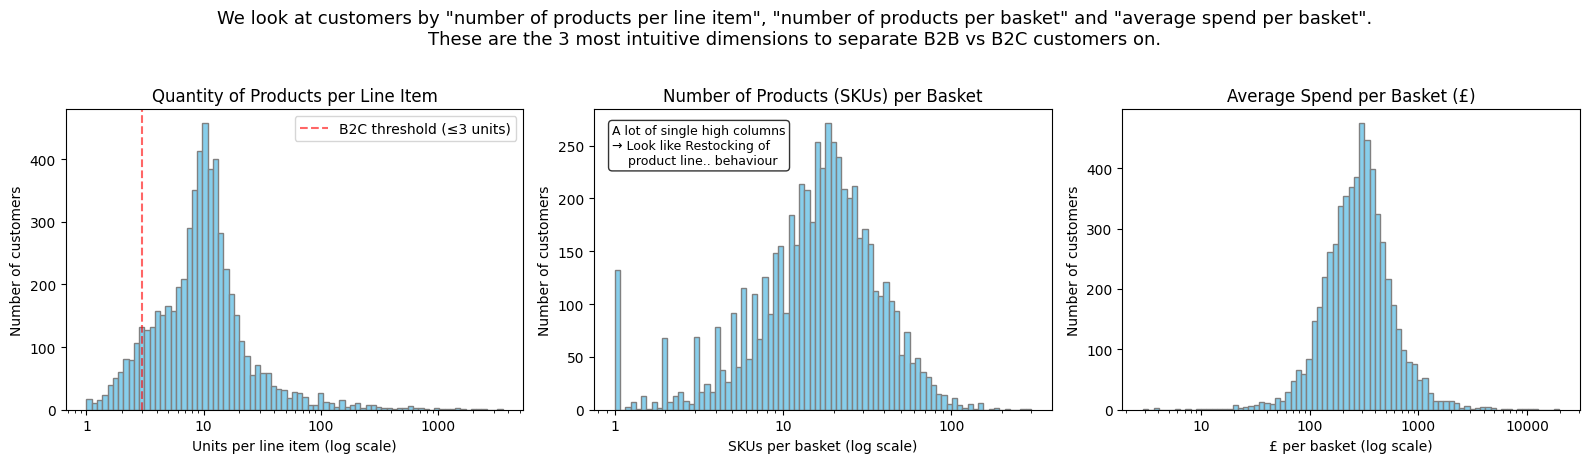

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

bins      = 80          # fewer bins on a log scale reads cleaner
color     = 'skyblue'
edgecolor = 'grey'

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('We look at customers by "number of products per line item", "number of products per basket" and "average spend per basket".\nThese are the 3 most intuitive dimensions to separate B2B vs B2C customers on.',
             fontsize=13, y=1.02)

# ── Plot 1: Avg quantity per line ─────────────────────────────────────────
# Use log-spaced bins so the histogram is evenly distributed on a log axis
qty   = customer['avg_qty_per_line'].clip(lower=0.5)
edges = np.logspace(np.log10(qty.min()), np.log10(qty.max()), bins)

ax[0].hist(qty, bins=edges, color=color, edgecolor=edgecolor)
ax[0].set_xscale('log')
ax[0].set_title('Quantity of Products per Line Item')
ax[0].set_xlabel('Units per line item (log scale)')
ax[0].set_ylabel('Number of customers')
ax[0].xaxis.set_major_formatter(mticker.ScalarFormatter())  # show 1, 10, 100 not 10^0

ax[0].axvline(3, color='red', ls='--', alpha=0.6,
              label='B2C threshold (≤3 units)')
ax[0].legend()


# ── Plot 2: Avg basket breadth ────────────────────────────────────────────
brd   = customer['avg_basket_breadth'].clip(lower=0.5)
edges = np.logspace(np.log10(brd.min()), np.log10(brd.max()), bins)

ax[1].hist(brd, bins=edges, color=color, edgecolor=edgecolor)
ax[1].set_xscale('log')
ax[1].set_title('Number of Products (SKUs) per Basket')
ax[1].set_xlabel('SKUs per basket (log scale)')
ax[1].set_ylabel('Number of customers')
ax[1].xaxis.set_major_formatter(mticker.ScalarFormatter())

ax[1].text(0.04, 0.95, 'A lot of single high columns\n→ Look like Restocking of\n    product line.. behaviour',
           transform=ax[1].transAxes, va='top', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# ── Plot 3: Avg basket value ──────────────────────────────────────────────
val   = customer['avg_basket_value'].clip(lower=1)
edges = np.logspace(np.log10(val.min()), np.log10(val.max()), bins)

ax[2].hist(val, bins=edges, color=color, edgecolor=edgecolor)
ax[2].set_xscale('log')
ax[2].set_title('Average Spend per Basket (£)')
ax[2].set_xlabel('£ per basket (log scale)')
ax[2].set_ylabel('Number of customers')
ax[2].xaxis.set_major_formatter(mticker.ScalarFormatter())


plt.tight_layout()
plt.show()

---
There is nothing obvious in the above to suggest B2C customers ..
- Let's plot item quantity versus basket breadth to see if there is any significant B2C concentration in the bottom left corner

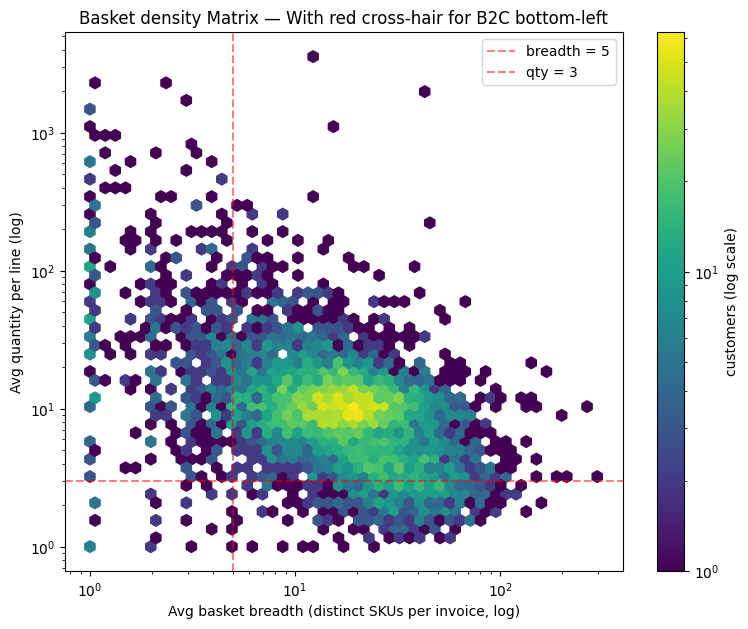

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

x = customer['avg_basket_breadth'].clip(lower=0.5)
y = customer['avg_qty_per_line'].clip(lower=0.5)

fig, ax = plt.subplots(figsize=(9,7))
hb = ax.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
               norm=LogNorm(), cmap='viridis', mincnt=1)
ax.set_xlabel('Avg basket breadth (distinct SKUs per invoice, log)')
ax.set_ylabel('Avg quantity per line (log)')
ax.set_title('Basket density Matrix — With red cross-hair for B2C bottom-left')
plt.colorbar(hb, ax=ax, label='customers (log scale)')

# Reference lines for a "B2C-like" zone
ax.axvline(5, color='red', ls='--', alpha=0.5, label='breadth = 5')
ax.axhline(3, color='red', ls='--', alpha=0.5, label='qty = 3')
ax.legend()
plt.show()

Those 4 graphs suggest this company is B2B only. 
- Even the 10^0 cluster far left is a vertical line going high on quantity suggesting stock replenishment for one or several products.

---
# Check for B2C specifically

In [5]:
b2c_candidates = customer[
    (customer['avg_qty_per_line']   <= 2)   &
    (customer['avg_basket_breadth'] >= 3)   &
    (customer['avg_basket_breadth'] <= 25)  &
    (customer['avg_basket_value']   <= 50)  &
    (customer['n_invoices']         <= 2)
].copy()

print(f"B2C-likeliest candidates: {len(b2c_candidates)} of {len(customer)} "
      f"({len(b2c_candidates)/len(customer):.1%})")

if len(b2c_candidates):
    cand_tx = df[df['CustomerHashID'].isin(b2c_candidates['CustomerHashID'])]
    print("\nTop products they buy:")
    print(cand_tx.groupby('Description').size()
                  .sort_values(ascending=False).head(20))
    print("\nCountry mix (by customer):")
    print("\nMedian profile:")
    print(b2c_candidates[['avg_basket_breadth','avg_qty_per_line',
                          'avg_basket_value','total_revenue']].median().round(2))

B2C-likeliest candidates: 6 of 5849 (0.1%)

Top products they buy:
Description
CHILLI LIGHTS                         2
AIRLINE BAG VINTAGE WORLD CHAMPION    1
RAIN PONCHO                           1
TEA TIME PARTY BUNTING                1
TABLECLOTH RED APPLES DESIGN          1
SWEETHEART 3 TIER CAKE STAND          1
SET OF 3 BLACK FLYING DUCKS           1
SEASIDE FLYING DISC                   1
SAVOY ART DECO CLOCK                  1
S 4 GROOVY CAT MAGNETS                1
ROSE DU SUD WASHBAG                   1
REX CASH CARRY JUMBO SHOPPER          1
RED WHITE DOTS RUFFLED UMBRELLA       1
RED SPOTTY WASHBAG                    1
RED HEARTS LIGHT CHAIN                1
RAIN PONCHO RETROSPOT                 1
PINK KNITTED COW STUFFED TOY          1
ALARM CLOCK BAKELIKE GREEN            1
PINK JUMPER LARRY THE LAMB            1
PARTY BUNTING                         1
dtype: int64

Country mix (by customer):

Median profile:
avg_basket_breadth     5.00
avg_qty_per_line       1.20
avg_bas

---
---
# We add more useful fields for analysis downstream

---
## Percentage case packs
 We add pack_size, is_pack_sku, is_case_pack_line_wholesale and is_case_pack_line_metric to identify bulk B2B purchases and purchase of sets
 - We split case-pack detection into two feature families: traditional UK wholesale multiples (base-6/12) and metric/Asian manufacturing multiples (base-5/10).
 - We also identify line items that themselves are packs

In [6]:
import re
import pandas as pd

# Traditional UK/European Wholesale (Base-6 / Base-12) common case pack multiples in B2B
pack_multiples_wholesale =[6, 12, 24, 36, 48, 72, 96, 120, 144, 288, 576]

# Modern/Asian Manufacturing (Base-5 / Base-10) common case pack multiples in B2B
pack_multiples_metric =[5, 10, 20, 50, 100, 500, 1000]

WORD_TO_NUM = {
    'TWO': 2, 'THREE': 3, 'FOUR': 4, 'FIVE': 5, 'SIX': 6,
    'SEVEN': 7, 'EIGHT': 8, 'NINE': 9, 'TEN': 10,
    'ELEVEN': 11, 'TWELVE': 12, 'FIFTEEN': 15, 'TWENTY': 20,
}

# 1. Pull pack size from Description (defaults to 1 = single) — kept on df for later use
# (PACK|SET|BOX), optionally OF, then either digits or a known number word
pack_pattern = re.compile(
    r'\b(?:PACK|SET|BOX)\s+(?:OF\s+)?(\d+|' + '|'.join(WORD_TO_NUM) + r')\b',
    re.IGNORECASE,
)

def detect_pack_size(desc):
    if pd.isna(desc):
        return 1
    m = pack_pattern.search(str(desc).upper())
    if not m:
        return 1
    val = m.group(1).upper()
    return int(val) if val.isdigit() else WORD_TO_NUM.get(val, 1)

df['pack_size']   = df['Description'].apply(detect_pack_size)
df['is_pack_sku'] = df['pack_size'] > 1


# Flag line as case-pack only if Quantity exactly matches one of these values
df['is_case_pack_line_wholesale'] = (df['Quantity'] > 0) & df['Quantity'].isin(pack_multiples_wholesale)
df['is_case_pack_line_metric'] = (df['Quantity'] > 0) & df['Quantity'].isin(pack_multiples_metric)


# 3. Aggregate to customer
pct_case_pack_wholesale = (df.groupby('CustomerHashID')['is_case_pack_line_wholesale']
                   .mean()
                   .rename('pct_case_pack_wholesale')
                   )
pct_case_pack_metric = (df.groupby('CustomerHashID')['is_case_pack_line_metric']
                   .mean()
                   .rename('pct_case_pack_metric')
                   )

# Merge into customer dataframe
customer = customer.merge(pct_case_pack_wholesale, on='CustomerHashID', how='left')
customer = customer.merge(pct_case_pack_metric, on='CustomerHashID', how='left')

# Calculate the total
customer['pct_case_pack_total'] = customer['pct_case_pack_wholesale'].fillna(0) + customer['pct_case_pack_metric'].fillna(0)


## We add percentage orders during business hours (UK) or evening weekend
- `pct_business_hours` and `pct_weekend` from `InvoiceDateMin`

In [7]:
# Business hours = Mon-Fri (weekday 0-4), 08:00 to 17:59 inclusive
# Evening hours = Mon-Fri 18:00-07:59 
# Weekends = Sat-Sun any time
# Treating all timestamps as UK time. No time saving hour change observed.

df['order_hour']    = df['InvoiceDateMin'].dt.hour
df['order_weekday'] = df['InvoiceDateMin'].dt.weekday   # 0=Mon, 6=Sun


is_weekday = df['order_weekday'].between(0, 4)

df['is_business_hours']    = is_weekday & df['order_hour'].between(8, 17)   # Mon-Fri 08:00-17:59
df['is_after_hours_wkday'] = is_weekday & ~df['order_hour'].between(8, 17)  # Mon-Fri 18:00-07:59
df['is_weekend']           = df['order_weekday'] >= 5                       # Sat-Sun any time


pct_hours = df.groupby('CustomerHashID').agg(
    pct_business_hours    = ('is_business_hours',    'mean'),
    pct_after_hours_wkday = ('is_after_hours_wkday', 'mean'),
    pct_weekend           = ('is_weekend',           'mean'),
)

customer = customer.drop(columns=['pct_business_hours','pct_after_hours_wkday','pct_weekend'], errors='ignore')
customer = customer.merge(pct_hours, on='CustomerHashID', how='left')

I should include the below but put it in a feature data validation section at the bottom

<Axes: title={'center': 'Order hour by BST vs GMT period'}, xlabel='order_hour'>

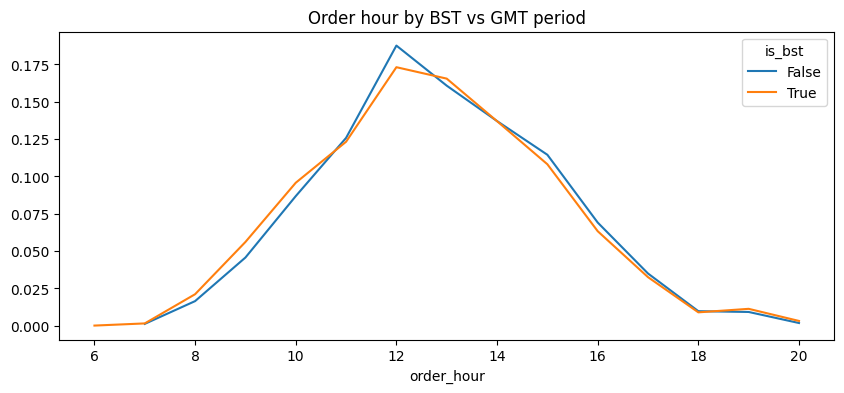

In [8]:
df['month']      = df['InvoiceDateMin'].dt.month
df['is_bst']     = df['month'].between(4, 10)   # rough BST window (Apr-Oct)

# Compare hour distributions for BST vs GMT periods
hour_dist = (df.groupby(['is_bst','order_hour']).size()
               .unstack(level=0)
               .div(df.groupby('is_bst').size()))    # normalise to proportion within each period
hour_dist.plot(kind='line', figsize=(10,4), title='Order hour by BST vs GMT period')

---
We update most common customer country as country_mode

In [9]:
# Most common country per customer (handles ties by taking the first alphabetically)
country_mode = (df.groupby('CustomerHashID')['Country']
                  .agg(lambda x: x.mode().iloc[0])
                  .rename('country_mode'))

customer = customer.drop(columns=['country_mode'], errors='ignore')
customer = customer.merge(country_mode, on='CustomerHashID', how='left')

we check how many customers order from multiple countries. 12

In [10]:
# How many customers ordered from more than one country?
multi_country = df.groupby('CustomerHashID')['Country'].nunique()
print('Customers with >1 country:', (multi_country > 1).sum())
print('Distribution:')
print(multi_country.value_counts().sort_index())

Customers with >1 country: 12
Distribution:
Country
1    5837
2      12
Name: count, dtype: int64


We look at monthly_revenue_trajectory — slope of monthly spend over their activity span (for lifecycle "growing/declining")

In [11]:
import numpy as np
from scipy.stats import linregress

def monthly_slope(group):
    monthly = group.set_index('InvoiceDateMin')['TotalPrice'].resample('ME').sum()
    if len(monthly) < 3:
        return np.nan
    return linregress(range(len(monthly)), monthly.values).slope

slopes = (df.groupby('CustomerHashID').apply(monthly_slope, include_groups=False)
            .rename('rev_slope'))

customer = customer.drop(columns=['rev_slope','rev_slope_pct'], errors='ignore')
customer = customer.merge(slopes, on='CustomerHashID', how='left')

# Normalised version — slope as % of avg monthly revenue, comparable across customer sizes
avg_monthly_rev = customer['total_revenue'] / (customer['active_span_days'] / 30.44)
customer['rev_slope_pct'] = customer['rev_slope'] / avg_monthly_rev

I am not sure about simple linear regtression for monthly trend as a feature. Let's look at an account:  

<Axes: title={'center': 'Monthly revenue: customer 72ed2bc3'}, xlabel='InvoiceDateMin'>

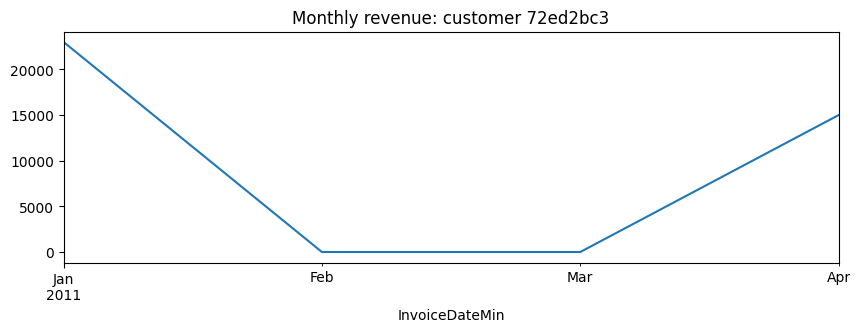

In [12]:
cust_chk = customer.loc[customer['rev_slope'].idxmin(), 'CustomerHashID'] 
inspect = (df[df['CustomerHashID'] == cust_chk]
           .set_index('InvoiceDateMin')['TotalPrice']
           .resample('ME').sum())
inspect.plot(title=f'Monthly revenue: customer {cust_chk[:8]}', figsize=(10,3))

the above graph shows that the liner trajectory is a bit blunt for this customer since this looks more like they stocked up in Jan 2011 and then only needed a restock in Apr so we need to take different types of activity like they order monthly etc.

---
We add active_months to assist with diagnosing this type of thing later
- I will look at it when I need it

In [13]:
# Number of active months — useful for filtering slopes downstream
n_active_months = (df.assign(month=df['InvoiceDateMin'].dt.to_period('M'))
                     .groupby('CustomerHashID')['month']
                     .nunique()
                     .rename('n_active_months'))

customer = customer.drop(columns=['n_active_months'], errors='ignore')
customer = customer.merge(n_active_months, on='CustomerHashID', how='left')

I just check the distribution

In [14]:
customer['n_active_months'].describe()

count    5849.000000
mean        4.352881
std         4.487245
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        25.000000
Name: n_active_months, dtype: float64

---
---
# We Look at Firmographic

In [ ]:
# Check the country list and count
uniq_country = customer.groupby('country_mode')['country_mode'].value_counts().sort_index()
print(uniq_country)

country_mode
AUSTRALIA                 14
AUSTRIA                   11
BAHRAIN                    2
BELGIUM                   28
BRAZIL                     2
CANADA                     5
CHANNEL ISLANDS           13
CYPRUS                    10
CZECH REPUBLIC             1
DENMARK                    9
EUROPEAN COMMUNITY         1
FINLAND                   13
FRANCE                    93
GERMANY                  106
GREECE                     5
ICELAND                    1
IRELAND                    3
ISRAEL                     4
ITALY                     17
JAPAN                     10
KOREA                      2
LEBANON                    1
LITHUANIA                  1
MALTA                      2
NETHERLANDS               22
NIGERIA                    1
NORWAY                    12
POLAND                     6
PORTUGAL                  22
SAUDI ARABIA               1
SINGAPORE                  1
SOUTH AFRICA               2
SPAIN                     35
SWEDEN                    19
S

---
## We apply the following groupings:
| **country_mode**     | **region**      | **sub_region**            | **count** |
| :------------------- | :-------------- | :------------------------ | :-------- |
| AUSTRALIA            | APAC            | OCEANIA                   | 14        |
| AUSTRIA              | EMEA            | EUROPE / DACH             | 11        |
| BAHRAIN              | EMEA            | MIDDLE EAST               | 2         |
| BELGIUM              | EMEA            | EUROPE / BENELUX          | 28        |
| BRAZIL               | AMER            | AMER / LATAM              | 2         |
| CANADA               | AMER            | AMER / NORAM              | 5         |
| CHANNEL ISLANDS      | CHANNEL ISLANDS | CHANNEL ISLANDS           | 13        |
| CYPRUS               | EMEA            | EUROPE / MEDITERRANEAN    | 10        |
| CZECH REPUBLIC       | EMEA            | EUROPE / CEE              | 1         |
| DENMARK              | EMEA            | EUROPE / NORDICS          | 9         |
| EUROPEAN COMMUNITY   | EMEA            | POLITICAL/REGIONAL ENTITY | 1         |
| FINLAND              | EMEA            | EUROPE / NORDICS          | 13        |
| FRANCE               | EMEA            | EUROPE / CENTRAL          | 93        |
| GERMANY              | EMEA            | EUROPE / DACH             | 106       |
| GREECE               | EMEA            | EUROPE / MEDITERRANEAN    | 5         |
| ICELAND              | EMEA            | EUROPE / NORDICS          | 1         |
| IRELAND              | EMEA            | EUROPE / NORTHERN         | 3         |
| ISRAEL               | EMEA            | MIDDLE EAST               | 4         |
| ITALY                | EMEA            | EUROPE / MEDITERRANEAN    | 17        |
| JAPAN                | APAC            | EAST ASIA                 | 10        |
| KOREA                | APAC            | EAST ASIA                 | 2         |
| LEBANON              | EMEA            | MIDDLE EAST               | 1         |
| LITHUANIA            | EMEA            | EUROPE / BALTICS          | 1         |
| MALTA                | EMEA            | EUROPE / MEDITERRANEAN    | 2         |
| NETHERLANDS          | EMEA            | EUROPE / BENELUX          | 22        |
| NIGERIA              | EMEA            | AFRICA                    | 1         |
| NORWAY               | EMEA            | EUROPE / NORDICS          | 12        |
| POLAND               | EMEA            | EUROPE / CEE              | 6         |
| PORTUGAL             | EMEA            | EUROPE / IBERIA           | 22        |
| SAUDI ARABIA         | EMEA            | MIDDLE EAST               | 1         |
| SINGAPORE            | APAC            | SOUTHEAST ASIA            | 1         |
| SOUTH AFRICA         | EMEA            | AFRICA                    | 2         |
| SPAIN                | EMEA            | EUROPE / IBERIA           | 35        |
| SWEDEN               | EMEA            | EUROPE / NORDICS          | 19        |
| SWITZERLAND          | EMEA            | EUROPE / DACH             | 22        |
| THAILAND             | APAC            | SOUTHEAST ASIA            | 1         |
| UNITED ARAB EMIRATES | EMEA            | MIDDLE EAST               | 4         |
| UNITED KINGDOM       | UK DOMESTIC     | UK DOMESTIC               | 5332      |
| UNITED STATES        | AMER            | AMER / NORAM              | 8         |
| UNSPECIFIED          | UNSPECIFIED     | UNSPECIFIED               | 6         |
| WEST INDIES          | AMER            | AMER / LATAM              | 1         |
| **TOTAL**            | **TOTAL**       | **TOTAL**                 | **5,849** |

In [23]:
# Country — actually present
customer['country_mode']

# Region — derived from country
def country_to_region(c):
    if c == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif c == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif c == 'UNSPECIFIED':
        return 'UNSPECIFIED'
    elif c in ['BRAZIL', 'CANADA', 'UNITED STATES', 'WEST INDIES']:
        return 'AMER'
    elif c in ['AUSTRALIA', 'JAPAN', 'KOREA' ,'SINGAPORE' ,'THAILAND']:
        return 'APAC'
    else:
        return 'EMEA'
    
# Sub-Region — derived from country
def country_to_subregion(cs):
    if cs == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif cs == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif cs == 'IRELAND':
        return 'EUROPE / NORTHERN'
    elif cs in ['BRAZIL', 'WEST INDIES']:
        return 'AMER / LATAM'
    elif cs in ['CANADA', 'UNITED STATES']:
        return 'AMER / NORAM'
    elif cs in ['AUSTRALIA']:
        return 'OCEANIA'
    elif cs == 'EUROPEAN COMMUNITY':
        return 'POLITICAL / REGIONAL ENTITY'
    elif cs in ['AUSTRIA', 'GERMANY', 'SWITZERLAND']:
        return 'EUROPE / DACH'
    elif cs in ['BELGIUM', 'NETHERLANDS']:
        return 'EUROPE / BENELUX'
    elif cs in ['CYPRUS', 'GREECE', 'ITALY', 'MALTA']:
        return 'EUROPE / MEDITERRANEAN'
    elif cs in ['CZECH REPUBLIC', 'POLAND']:
        return 'EUROPE / CEE'
    elif cs in ['DENMARK', 'FINLAND', 'ICELAND', 'NORWAY', 'SWEDEN']:
        return 'EUROPE / NORDICS'
    elif cs in ['FRANCE']:
        return 'EUROPE / CENTRAL'
    elif cs in ['LITHUANIA']:
        return 'EUROPE / BALTICS'
    elif cs in ['PORTUGAL', 'SPAIN']:
        return 'EUROPE / IBERIA'
    elif cs in ['BAHRAIN', 'ISRAEL', 'LEBANON', 'SAUDI ARABIA', 'UNITED ARAB EMIRATES']:
        return 'MIDDLE EAST'
    elif cs in ['JAPAN', 'KOREA']:
        return 'EAST ASIA'
    elif cs in ['SINGAPORE' ,'THAILAND']:
        return 'SOUTHEAST ASIA'
    elif cs in ['NIGERIA', 'SOUTH AFRICA']:
        return 'AFRICA'
    else:
        return 'UNSPECIFIED'

customer['region'] = customer['country_mode'].apply(country_to_region)
customer['sub_region'] = customer['country_mode'].apply(country_to_subregion)

In [25]:
# Check the region list and count
# Option 3 — as a tidy DataFrame with a named count column (nicest for further use)
uniq_region = (customer.groupby(['region','sub_region'])
                       .size()
                       .reset_index(name='n_customers')
                       .sort_values(['region','sub_region']))
print(uniq_region)

             region                   sub_region  n_customers
0              AMER                 AMER / LATAM            3
1              AMER                 AMER / NORAM           13
2              APAC                    EAST ASIA           12
3              APAC                      OCEANIA           14
4              APAC               SOUTHEAST ASIA            2
5   CHANNEL ISLANDS              CHANNEL ISLANDS           13
6              EMEA                       AFRICA            3
7              EMEA             EUROPE / BALTICS            1
8              EMEA             EUROPE / BENELUX           50
9              EMEA                 EUROPE / CEE            7
10             EMEA             EUROPE / CENTRAL           93
11             EMEA                EUROPE / DACH          139
12             EMEA              EUROPE / IBERIA           57
13             EMEA       EUROPE / MEDITERRANEAN           34
14             EMEA             EUROPE / NORDICS           54
15      

---
---
# RFM and Seasonality

---
---
---
---
---
---
---
---
---
---